# Tutorial

This notebook presents a complete example of how to use the `sciml` package to solve, with a PINN, the one-dimensional steady-state advection–diffusion problem parametrized by the Peclet number.

**Problem definition:**

$$
    \begin{cases}
        u_{xx} - Pe u_x = 0,
        & (x, Pe) \in [0, 1] \times [Pe_{\min}, Pe_{\max}], \\
        u(0, Pe) = 1,
        & Pe \in [Pe_{\min}, Pe_{\max}], \\
        u(1, Pe) = 0,
        & Pe \in [Pe_{\min}, Pe_{\max}].
    \end{cases}
$$

**Analytical solution:**

$$
    u(x, Pe) = \frac{1 - \exp(Pe(x - 1))}{1 - \exp(-Pe)}.
$$

## 1. Packages
---

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pathlib import Path

from sciml.losses import Supervised, Residual
from sciml.metrics import MeanRelativeAbsoluteError, MaxError
from sciml.samplers import LatinHypercube, Scaler
from sciml.trainers import Standard
from sciml.callbacks import Logger
from sciml.utils import initialization
from sciml.utils.posproc import plot_history, summarize

## 2. Parameters and settings
---

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(1234)
np.random.seed(1234)

# Define device and data type
DEVICE = "cpu"
DTYPE = torch.float32

# Define results directory
RESULTS_DIR = Path("./results/standard/")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Define neural network
INPUT_DIM = 2
OUTPUT_DIM = 1
HIDDEN_LAYERS = [10, 10]

# Define problem parameters
PE_MIN = 0.0
PE_MAX = 10.0

# Define training parameters
N_RESIDUAL = 2000
N_BOUNDARY = 500
N_VALIDATION = 5000

BATCH_RESIDUAL = N_RESIDUAL
BATCH_BOUNDARY = N_BOUNDARY
BATCH_VALIDATION = 5000

ITERATIONS = 5000

# Transform normalize data
scaler = Scaler(bounds=[(0, 1), (PE_MIN, PE_MAX)])

## 3. Analytical solution
---

In [3]:
# Define the analytical solution of the advection-diffusion equation
def solution(data: np.ndarray, eps: float = 1e-3) -> np.ndarray:
    """Compute the analytical solution of the advection-diffusion equation."""
    data = scaler.transform(data)
    x = data[:, 0:1]
    peclet = data[:, 1:2].clip(min=eps)
    return (1 - np.exp(peclet * (x - 1))) / (1 - np.exp(-peclet))

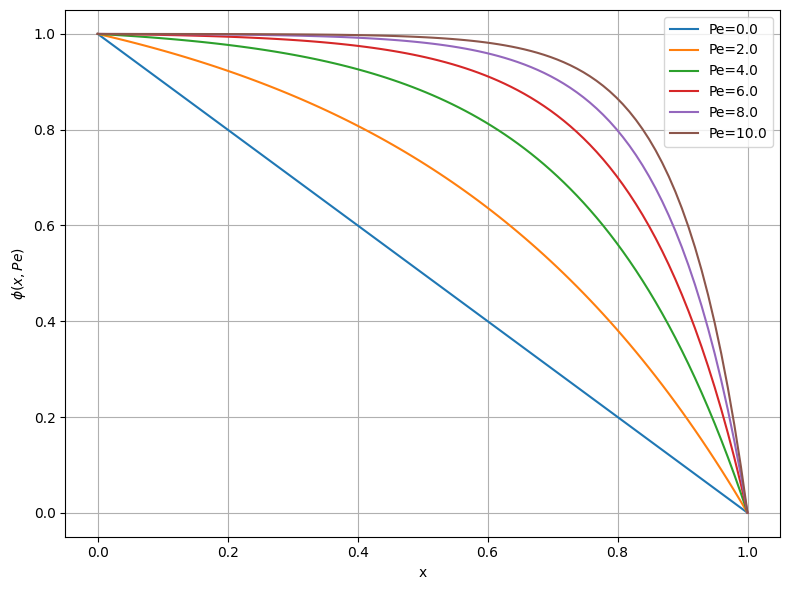

In [4]:
# Define the spatial and parameter domains
x = np.linspace(0, 1, 100)
peclet = np.arange(0, 1.2, 0.2)

# Plot the analytical solution
plt.figure(figsize=(8, 6))
for p in peclet:

    # Compute analytical solution
    data = np.column_stack((x, np.full_like(x, p)))
    u_ref = solution(data)

    # Scale peclet
    p = scaler.transform(data)[0, 1]

    plt.plot(x, u_ref, label=f"Pe={p:.1f}")

plt.ylabel(r"$\phi(x, Pe)$")
plt.xlabel("x")
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

## 4. Components
---

### 4.1. Neural network

In [5]:
# Define the neural network architecture
class MLP(torch.nn.Module):
    """Simple fully-connected neural network."""

    def __init__(
            self,
            input_dim: int,
            output_dim: int,
            hidden_layers: tuple[int, ...] = (64, 64, 64),
            activation: type[torch.nn.Module] = torch.nn.Tanh,
        ) -> None:
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(torch.nn.Linear(previous_dim, hidden_dim))
            layers.append(activation())
            previous_dim = hidden_dim

        layers.append(torch.nn.Linear(previous_dim, output_dim))

        self.net = torch.nn.Sequential(*layers)

        return

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [6]:
# Define the neural network
network = MLP(
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_layers=HIDDEN_LAYERS,
).to(device=DEVICE, dtype=DTYPE)

network.apply(initialization.xavier_normal)

MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): Tanh()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

### 4.2. Losses

In [7]:
# Define the residual loss
class ResidualLoss(Residual):
    """Residual loss for phi_xx - Pe * phi_x = 0."""

    def residual(self, network: torch.nn.Module, data: dict[str, torch.Tensor]) -> torch.Tensor:

        # Extract the input data
        x, peclet = data["xp"][:, 0:1], data["xp"][:, 1:2]

        # Enable gradient computation
        x.requires_grad_(True)

        # Concatenate inputs
        xp = torch.cat([x, peclet], dim=1)

        # Compute the network output
        phi = network(xp)

        # Compute the first and second derivatives of phi with respect to x
        phi_x = self.derivative(phi, x)
        phi_xx = self.derivative(phi_x, x)

        # Scale data
        # xp = scaler.transform(xp)
        peclet = peclet * PE_MAX # xp[:, 1:2]

        return (phi_xx - peclet * phi_x) / (1 + peclet)

# Define the losses
residual_loss = ResidualLoss(
    name="residual",
    weight=1.0,
)

left_bc_loss = Supervised(
    name="left_bc",
    weight=1.0,
    input_key="xp",
    target_key="u",
)

right_bc_loss = Supervised(
    name="right_bc",
    weight=1.0,
    input_key="xp",
    target_key="u",
)

losses = [residual_loss, left_bc_loss, right_bc_loss]

### 4.3. Samplers

In [8]:
# Define the samplers
residual_sampler = LatinHypercube(
    name="residual",
    n_points=N_RESIDUAL,
    batch_size=BATCH_RESIDUAL,
    bounds=[(0, 1), (0, 1)],
    margin=[1e-2, 0.0],
    input_key="xp",
    seed=1,
    device=DEVICE,
    dtype=DTYPE,
)

left_bc_sampler = LatinHypercube(
    name="left_bc",
    n_points=N_BOUNDARY,
    batch_size=BATCH_BOUNDARY,
    bounds=[(0, 1)],
    insertions=[(0, 0.0)],
    input_key="xp",
    target_key="u",
    target_fn=solution,
    seed=2,
    device=DEVICE,
    dtype=DTYPE,
)

right_bc_sampler = LatinHypercube(
    name="right_bc",
    n_points=N_BOUNDARY,
    batch_size=BATCH_BOUNDARY,
    bounds=[(0, 1)],
    insertions=[(0, 1.0)],
    input_key="xp",
    target_key="u",
    target_fn=solution,
    seed=3,
    device=DEVICE,
    dtype=DTYPE,
)

validation_sampler = LatinHypercube(
    name="validation",
    n_points=N_VALIDATION,
    batch_size=BATCH_VALIDATION,
    bounds=[(0, 1), (0, 1)],
    input_key="xp",
    target_key="u",
    target_fn=solution,
    seed=4,
    device=DEVICE,
    dtype=DTYPE,
)

samplers = [residual_sampler, left_bc_sampler, right_bc_sampler]

## 5. Training
---

Settings

In [ ]:
# Define the optimizer
optimizer = torch.optim.Adam(network.parameters())

# Define the metrics
metrics = [MeanRelativeAbsoluteError(), MaxError()]

# Define the logger
logger = Logger(
    directory=str(RESULTS_DIR / "logs"),
    loss_names=[loss.name for loss in losses],
    metric_names=[metric.name for metric in metrics],
    frequency=10,
)

# Define the trainer
trainer = Standard(
    network=network,
    losses=losses,
    samplers=samplers,
    optimizer=optimizer,
    metrics=metrics,
    validation_sampler=validation_sampler,
    validation_frequency=10,
    logger=logger,
)

Optimize

In [10]:
trainer.fit(iterations=ITERATIONS, verbose=True)

     iteration          total       residual        left_bc       right_bc           mrae      max_error
-------------- -------------- -------------- -------------- -------------- -------------- --------------
             1   1.316852e+00   1.919718e-02   1.288677e+00   8.977157e-03              -              -
             2   1.283894e+00   1.714563e-02   1.257788e+00   8.960362e-03              -              -
             3   1.251461e+00   1.521639e-02   1.227236e+00   9.009071e-03              -              -
             4   1.219568e+00   1.341097e-02   1.197033e+00   9.123547e-03              -              -
             5   1.188227e+00   1.173062e-02   1.167192e+00   9.304014e-03              -              -
             6   1.157450e+00   1.017641e-02   1.137723e+00   9.550652e-03              -              -
             7   1.127248e+00   8.749122e-03   1.108635e+00   9.863573e-03              -              -
             8   1.097630e+00   7.449333e-03   1.079938

## 6. Post-process
---

### 6.1. Losses and metrics history

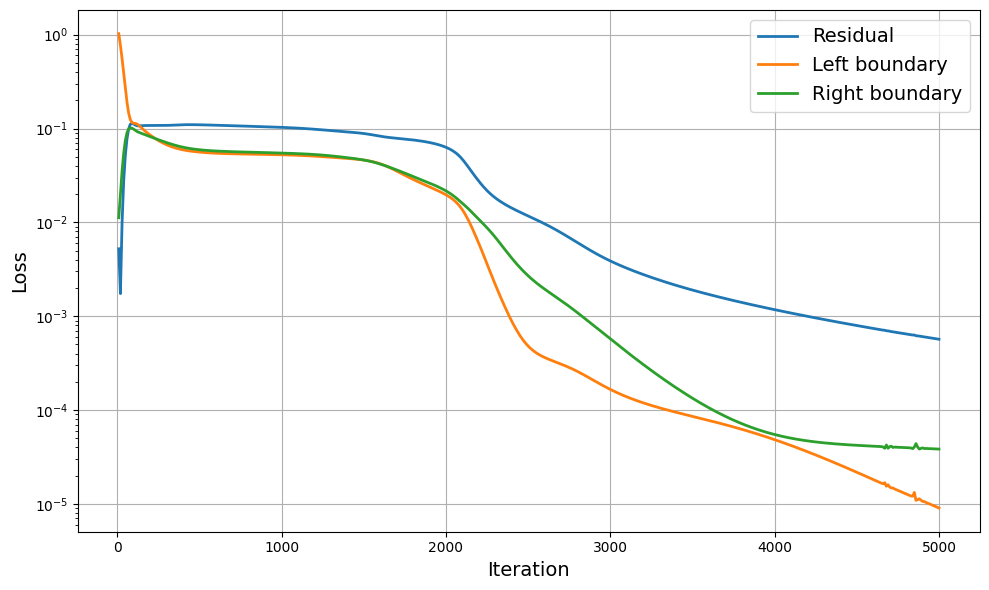

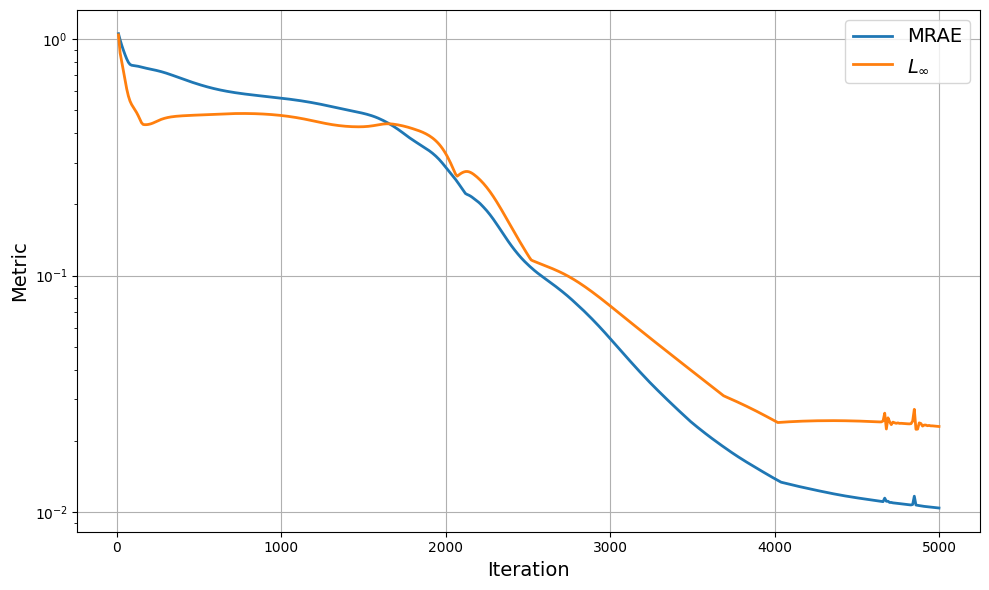

In [11]:
history = logger.to_dataframe()

plot_history(
    df=history,
    y_keys=["residual", "left_bc", "right_bc"],
    x_key="iteration",
    labels={"residual": "Residual", "left_bc": "Left boundary", "right_bc": "Right boundary"},
    xlabel="Iteration",
    ylabel="Loss",
)

plot_history(
    df=history,
    y_keys=[metric.name for metric in metrics],
    x_key="iteration",
    labels={"mrae": "MRAE", "max_error": "$L_\infty$"},
    xlabel="Iteration",
    ylabel="Metric",
)

### 6.2. Summary

In [12]:
info = summarize(
    df=history,
    keys=["residual", "left_bc", "right_bc"] + [metric.name for metric in metrics],
    iteration_key="iteration",
    last_n=20,
    mode="min",
)

print(info)

      metric   initial     final      best  best_iteration  mean_last_20  \
0   residual  0.005234  0.000569  0.000569            5000      0.000605   
1    left_bc  1.023745  0.000009  0.000009            5000      0.000011   
2   right_bc  0.011200  0.000038  0.000038            5000      0.000039   
3       mrae  1.050305  0.010429  0.010429            5000      0.010663   
4  max_error  1.038600  0.023038  0.022418            4860      0.023501   

   std_last_20  improvement_abs  improvement_rel  
0     0.000023         0.004665         0.891302  
1     0.000001         1.023736         0.999991  
2     0.000001         0.011162         0.996569  
3     0.000270         1.039876         0.990070  
4     0.000979         1.015562         0.977818  


### 6.3. Analytical solution comparison

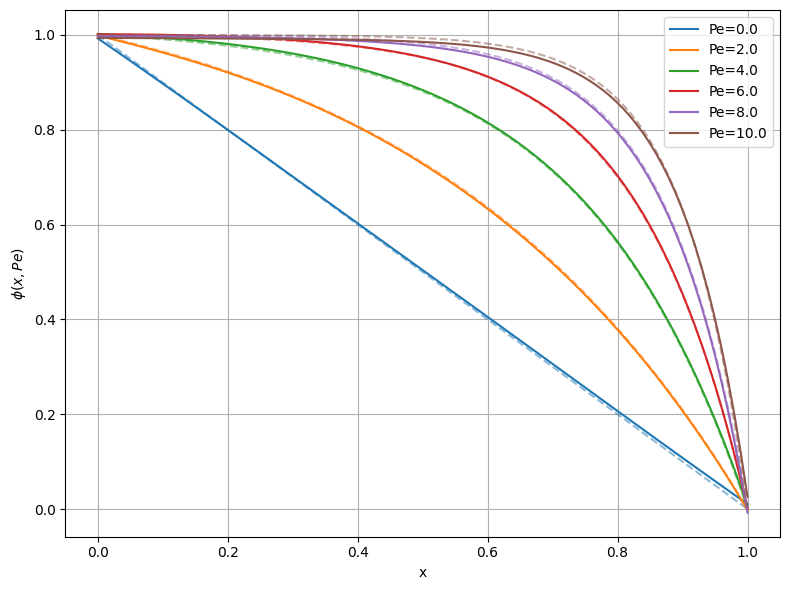

In [13]:
# Define the spatial and parameter domains
x = np.linspace(0, 1, 100)
peclet = np.arange(0, 1.2, 0.2)

# Set network in evaluation mode
network.eval()

# Plot the analytical solution
plt.figure(figsize=(8, 6))
for p in peclet:

    # Compute analytical solution
    data = np.column_stack((x, np.full_like(x, p)))
    u_ref = solution(data).squeeze()

    # Compute predicted solution
    data = torch.from_numpy(data).to(dtype=DTYPE)
    u_pred = network(data).detach().numpy().squeeze()
    
    # Scale peclet
    p = scaler.transform(data)[0, 1].item()

    line, = plt.plot(x, u_pred, label=f"Pe={p:.1f}")
    plt.plot(x, u_ref, "--", color=line.get_color(), alpha=0.5)

plt.ylabel(r"$\phi(x, Pe)$")
plt.xlabel("x")
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

### 6.4. Absolute error

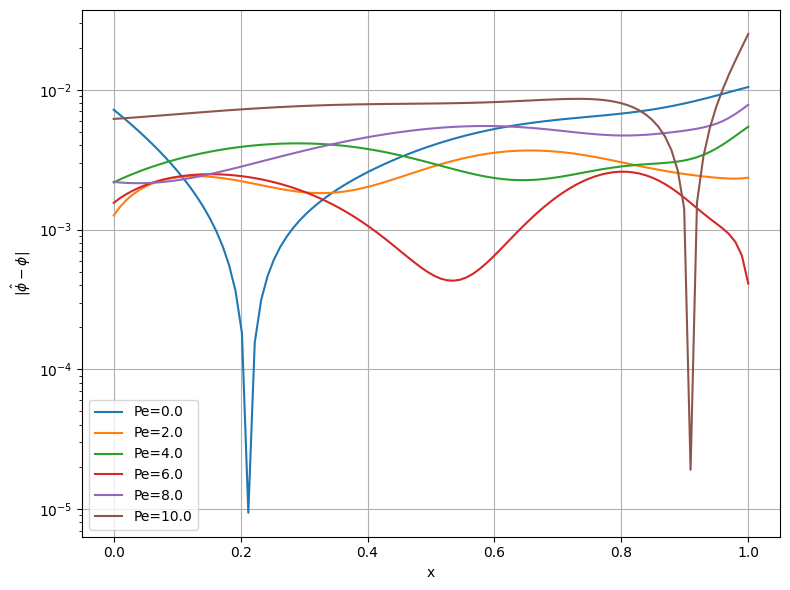

In [14]:
# Define the spatial and parameter domains
x = np.linspace(0, 1, 100)
peclet = np.arange(0, 1.2, 0.2)

# Set network in evaluation mode
network.eval()

# Plot the analytical solution
plt.figure(figsize=(8, 6))
for p in peclet:

    # Compute analytical solution
    data = np.column_stack((x, np.full_like(x, p)))
    u_ref = solution(data).squeeze()

    # Compute predicted solution
    data = torch.from_numpy(data).to(dtype=DTYPE)
    u_pred = network(data).detach().numpy().squeeze()

    # Scale peclet
    p = scaler.transform(data)[0, 1].item()

    plt.plot(x, np.abs(u_pred - u_ref), label=f"Pe={p:.1f}")

plt.ylabel(r"$|\hat{\phi} - \phi|$")
plt.xlabel("x")
plt.yscale("log")
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()